In [222]:
from io import StringIO

import pandas as pd
import numpy as np
import scipy
from scipy.linalg import eigh

import gzip

import anndata as ad

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference

import skfda
from skfda.representation.basis import BSplineBasis, MonomialBasis

import seaborn as sns
import matplotlib.pyplot as plt

In [223]:
# edgeR size factors 
import numpy as np

def calc_tmm_size_factors(X, ref_index=None, 
                          logratio_trim=0.3, 
                          sum_trim=0.05,
                          weight=True):
    """
    Compute TMM normalization factors (edgeR-style).
    
    Parameters
    ----------
    X : np.ndarray
        Raw count matrix (samples x genes)
    ref_index : int or None
        Reference sample index. If None, uses median library size sample.
    logratio_trim : float
        Proportion to trim from M-values (default 0.3)
    sum_trim : float
        Proportion to trim from A-values (default 0.05)
    weight : bool
        Whether to use delta-method weights
    
    Returns
    -------
    size_factors : np.ndarray
        TMM normalization factors (geometric mean scaled to 1)
    """

    X = np.asarray(X, dtype=float)
    lib_sizes = X.sum(axis=1)

    # Choose reference sample
    if ref_index is None:
        ref_index = np.argsort(lib_sizes)[len(lib_sizes)//2]

    ref = X[ref_index]
    ref_lib = lib_sizes[ref_index]

    factors = []

    for i in range(X.shape[0]):
        if i == ref_index:
            factors.append(1.0)
            continue

        obs = X[i]
        obs_lib = lib_sizes[i]

        # Keep genes expressed in both
        mask = (obs > 0) & (ref > 0)
        obs = obs[mask]
        ref_g = ref[mask]

        if len(obs) == 0:
            factors.append(1.0)
            continue

        # M and A values
        M = np.log2((obs / obs_lib) / (ref_g / ref_lib))
        A = 0.5 * np.log2((obs / obs_lib) * (ref_g / ref_lib))

        # Weights
        if weight:
            w = 1.0 / ((1/obs) - (1/obs_lib) + (1/ref_g) - (1/ref_lib))
        else:
            w = np.ones_like(M)

        # Trim M
        lo_M, hi_M = np.quantile(M, [logratio_trim/2, 1-logratio_trim/2])
        keep_M = (M >= lo_M) & (M <= hi_M)

        # Trim A
        lo_A, hi_A = np.quantile(A, [sum_trim/2, 1-sum_trim/2])
        keep_A = (A >= lo_A) & (A <= hi_A)

        keep = keep_M & keep_A

        M = M[keep]
        w = w[keep]

        if len(M) == 0:
            factors.append(1.0)
            continue

        tmm = np.sum(w * M) / np.sum(w)

        factors.append(2**tmm)

    factors = np.array(factors)

    # Scale to geometric mean = 1 (edgeR convention)
    factors /= np.exp(np.mean(np.log(factors)))

    return factors

In [224]:
# load in adata and metadata
adata = ad.read_h5ad('./oas1/gse190001_isoform.h5ad')


In [225]:
adata.obs['patient'] = adata.obs['sample_alias'].str.split('_').str[0]
adata.obs['dose_time'] = adata.obs['sample_alias'].str.split('_').str[1]
adata.obs['time'] = adata.obs['dose_time'].str.split('D').str[1].astype(int)
adata.obs['dose'] = adata.obs['dose_time'].str.split('D').str[0]

In [226]:
adata.X = np.array(adata.X.todense())

In [227]:
tmms = calc_tmm_size_factors(adata.X)
ls = adata.X.sum(axis=1)
els = tmms*ls 
norm_counts = 1e6 * adata.X / els[:,None]

In [228]:
adata.layers['norm'] = norm_counts

In [229]:
adata.obs.patient.unique()

array(['CVX6', 'CVX26', 'CVX5', 'CVX25', 'CVX18', 'CVX17', 'CVX4',
       'CVX16', 'CVX13', 'CVX12', 'CVX11', 'CVX10', 'CVX9', 'CVX3',
       'CVX2', 'CVX1', 'CVX15', 'CVX14', 'CVX21', 'CVX20', 'CVX19',
       'CVX8', 'CVX7'], dtype=object)

In [230]:
# visualize a gene over time
exp = adata[(adata.obs.patient=='CVX6') & (adata.obs.dose == 'C1')].X
t = adata[(adata.obs.patient=='CVX6') & (adata.obs.dose == 'C1')].obs.time

In [231]:
# get oas1 transcripts
# !wget -O OAS1_transcripts.tsv \
# "https://www.ensembl.org/biomart/martservice?query=<?xml version='1.0' encoding='UTF-8'?>
# <!DOCTYPE Query>
# <Query virtualSchemaName='default' formatter='TSV' header='1' uniqueRows='1' count=''>
#   <Dataset name='hsapiens_gene_ensembl' interface='default'>
#     <Filter name='ensembl_gene_id' value='ENSG00000089127'/>
#     <Attribute name='ensembl_gene_id'/>
#     <Attribute name='ensembl_transcript_id'/>
#     <Attribute name='transcript_biotype'/>
#   </Dataset>
# </Query>"
oas_transcripts = pd.read_csv('oas1/OAS1_transcripts.tsv',sep='\t')

In [232]:
adata.var['ENST'] = adata.var.index.str.split('.').str[0]

In [233]:
adata_oas1 = adata[:,adata.var.ENST.isin(oas_transcripts['Transcript stable ID'].values)]
oas_sum = adata_oas1.X.sum(axis=0)
oas_exp_map = {adata_oas1.var.ENST.values[i] : oas_sum[i] for i in range(33)}
oas_transcripts['Exp'] = oas_transcripts['Transcript stable ID'].map(oas_exp_map)

In [234]:
hot = oas_transcripts[ oas_transcripts.Exp > 500]

In [235]:
def plot_transcript_over_time(adata, transcript_id):
    """
    Plot expression of one transcript over time.
    Hue = dose
    Shaded region = std across patients
    """

    # --- Extract expression vector efficiently ---
    idx = np.where(adata.var.ENST.values == t)[0][0]
    
    if sparse.issparse(adata.X):
        expr = adata.X[:, idx].toarray().ravel()
    else:
        expr = adata.X[:, idx]

    # --- Build minimal dataframe ---
    df = pd.DataFrame({
        "expression": expr,
        "time": adata.obs["time"].values,
        "dose": adata.obs["dose"].values,
        "patient": adata.obs["patient"].values
    })

    # --- Aggregate over patients ---
    summary = (
        df.groupby(["dose", "time"])
          .agg(mean_expression=("expression", "mean"),
               sd_expression=("expression", "std"))
          .reset_index()
    )

    # --- Plot ---
    plt.figure()

    for dose, sub in summary.groupby("dose"):
        sns.lineplot(
            data=sub,
            x="time",
            y="mean_expression",
            label=str(dose)
        )
        plt.fill_between(
            sub["time"],
            sub["mean_expression"] - sub["sd_expression"],
            sub["mean_expression"] + sub["sd_expression"],
            alpha=0.2
        )

    plt.xlabel("Time")
    plt.ylabel("Expression")
    plt.title(f"{transcript_id} expression over time")
    plt.legend(title="Dose")
    plt.grid(True)
    plt.show()

In [241]:
# according to https://www.ensembl.org/Homo_sapiens/Gene/Summary?g=ENSG00000089127;r=12:112905856-112933219
# and https://www.uniprot.org/uniprotkb/P00973/entry#P00973-1

# p46: P00973-1: ENST00000202917, ENST00000680189, ENST00000681934'
# p42: P00973-2: ENST00000452357, 

uniprot_map = {'ENST00000202917' : 'p46',
               'ENST00000680189' : 'p46',
               'ENST00000681934' : 'p46',
               'ENST00000452357' : 'p42',
               'ENST00000551241' : 'p44',
               'ENST00000445409' : 'p48',
              }

In [242]:
oas_transcripts['p'] = oas_transcripts['Transcript stable ID'].map(uniprot_map)
oas_transcripts['tp'] = oas_transcripts['Transcript stable ID'].astype(str) + '_' + oas_transcripts.p.astype(str)

In [243]:
oas_p = oas_transcripts.dropna()

In [244]:
oas_p

,Gene stable ID,Transcript stable ID,Transcript type,Exp,p,tp
0,ENSG00000089127,ENST00000680189,protein_coding,682.811707,p46,ENST00000680189_p46
1,ENSG00000089127,ENST00000452357,protein_coding,18197.335938,p42,ENST00000452357_p42
2,ENSG00000089127,ENST00000445409,protein_coding,2955.753906,p48,ENST00000445409_p48
8,ENSG00000089127,ENST00000202917,protein_coding,0.000000,p46,ENST00000202917_p46
19,ENSG00000089127,ENST00000681934,nonsense_mediated_decay,10.857790,p46,ENST00000681934_p46
23,ENSG00000089127,ENST00000551241,protein_coding,1071.789795,p44,ENST00000551241_p44


In [294]:
oas_p_fit = oas_p[oas_p['Transcript stable ID'].isin(['ENST00000680189','ENST00000452357'])]

ENST00000680189
ENST00000452357
ENST00000680189
ENST00000452357


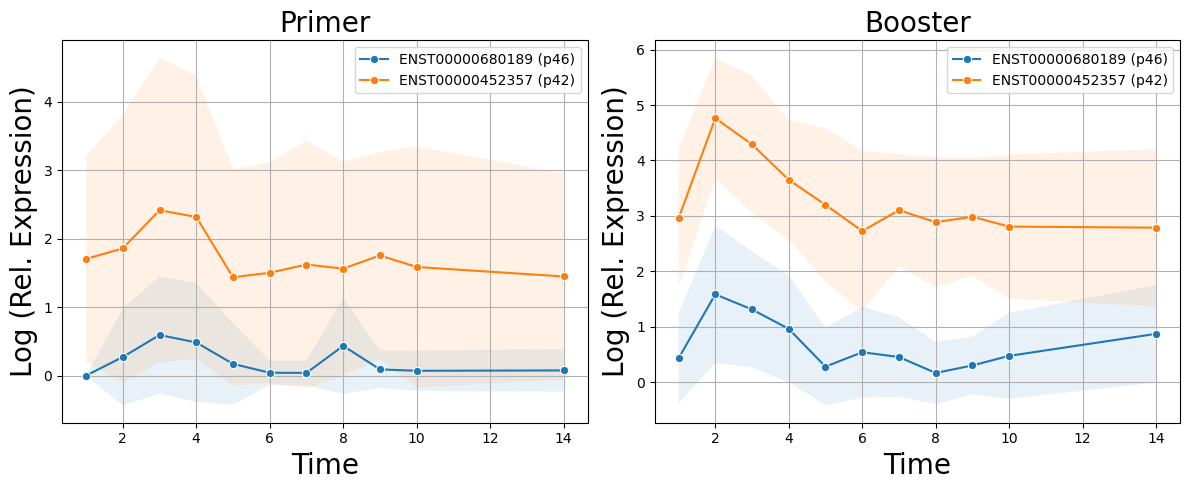

In [317]:
dose_filters = ['C1','C2']
titles = ['Primer','Booster']
log1p = True
transcripts = oas_p_fit['Transcript stable ID'].values

i = 0 
fig,ax = plt.subplots(1,2,figsize=(12, 5))
for t,dose_filter in enumerate(dose_filters):
    title = titles[t]
    if dose_filter is not None:
        obs_mask = adata.obs["dose"] == dose_filter
        adata_sub = adata[obs_mask]
    else:
        adata_sub = adata
    


    for i, transcript in enumerate(transcripts):
        idx = np.where(adata_sub.var.ENST == transcript)[0][0]
        if sparse.issparse(adata_sub.X):
            expr = adata_sub.X[:, idx].toarray().ravel()
        else:
            expr = adata_sub.X[:, idx]
        if log1p:
                expr = np.log1p(expr)
        
        df = pd.DataFrame({
            "expression": expr,
            "time": adata_sub.obs["time"].values,
            "patient": adata_sub.obs["patient"].values
        })
    
        # Aggregate by time across patients
        summary = (
            df.groupby("time")
              .agg(mean_expression=("expression", "mean"),
                   sd_expression=("expression", "std"))
              .reset_index()
        )
    
        # --- Plot ---
        # plt.subplot(len(transcripts), 1, i + 1)
        sns.lineplot(
            data=summary,
            x="time",
            y="mean_expression",
            marker="o",
            label= transcript + f' ({uniprot_map[transcript]})',
            ax = ax[t]
        )
        ax[t].fill_between(
            summary["time"],
            summary["mean_expression"] - summary["sd_expression"],
            summary["mean_expression"] + summary["sd_expression"],
            alpha=0.1
        )
        print(transcript)
        ax[t].set_xlabel("Time",fontsize=20)
        ax[t].set_ylabel("Log (Rel. Expression)",fontsize=20)
        ax[t].legend()
        ax[t].grid(True)
        ax[t].set_title(title,fontsize=20)
    i+=1

plt.tight_layout()
plt.show()

# Perform f-rhoPCA on OAS1 transcripts

In [296]:
import skfda
from skfda.datasets import fetch_growth
from skfda.preprocessing.dim_reduction import FPCA
from skfda.representation.basis import BSplineBasis, MonomialBasis

from sklearn.metrics import silhouette_score

from scipy.linalg import eigh

In [297]:
def get_fd(df_prime_clean, df_boost_clean):

  indices = df_boost_clean.groupby('patient')['t'].apply(lambda x: x.values).tolist()
  values = df_boost_clean.groupby('patient')['count_rel'].apply(lambda x: x.values).tolist()

  fd_boost = skfda.representation.irregular.FDataIrregular(
      start_indices=np.cumsum([0] + [len(i) for i in indices[:-1]]),
      points=np.concatenate(indices),
      values=np.concatenate(values)
  )

  indices = df_prime_clean.groupby('patient')['t'].apply(lambda x: x.values).tolist()
  values = df_prime_clean.groupby('patient')['count_rel'].apply(lambda x: x.values).tolist()

  fd_prime = skfda.representation.irregular.FDataIrregular(
      start_indices=np.cumsum([0] + [len(i) for i in indices[:-1]]),
      points=np.concatenate(indices),
      values=np.concatenate(values)
  )

  return(fd_prime,fd_boost)


def get_coefficients(df,fd,basis):
  t_min, t_max = df['t'].min(), df['t'].max()
  fd_basis = fd.to_basis(basis)
  coefficients = fd_basis.coefficients
  return(coefficients)


# now do rhoPCA
def rho_fpca_basis(A_fg, A_bg, basis, eps=1e-6):
    """
    Functional ρPCA in basis using Gram-matrix geometry. Returns coefficients of evecs for basis.
    """
    G = basis.gram_matrix()
    A_fg_c = A_fg - A_fg.mean(axis=0)
    A_bg_c = A_bg - A_bg.mean(axis=0)

    l_matrix = np.linalg.cholesky(G)
    l_inv_g_t = scipy.linalg.solve_triangular(
            l_matrix,
            np.transpose(G),
            lower=True)

    whitened_fg = A_fg_c @ np.transpose(l_inv_g_t)
    whitened_bg = A_bg_c @ np.transpose(l_inv_g_t)

    cov_fg = np.cov(whitened_fg, rowvar=False)
    cov_bg = np.cov(whitened_bg, rowvar=False)

    # vals, vecs = eigh(cov_fg , cov_bg + np.eye(len(cov_fg))*eps)
    try:
        vals, vecs = eigh(cov_fg , cov_bg)
    except:
        eps = 1e-6
        vals, vecs = eigh(cov_fg , cov_bg + np.eye(len(cov_fg))*eps)
        
    vecs = scipy.linalg.solve_triangular(l_matrix.T, vecs, lower=False)   # the vectors are not transposed like in sklearn-fpca because eigh has different convention than PCA


    # return vals[idx], vecs[:, idx]
    # fix convention of returned vecs
    for i,vec_ in enumerate(vecs.T):
        max_ = np.where(np.abs(vec_) == np.max(np.abs(vec_)))[0]
        if vec_[max_] < 0:
            vec_ *= -1
        vecs[:,i] = vec_

    GE1_coeffs = vecs[:,-1]
    GE2_coeffs = vecs[:,-2]

    GE1_fd = skfda.representation.basis.FDataBasis(basis, GE1_coeffs)
    GE2_fd = skfda.representation.basis.FDataBasis(basis, GE2_coeffs)

    return vals, vecs, GE1_fd, GE2_fd

def r2_mask(fd_irregular, basis, threshold=0.8):

    fd_basis = fd_irregular.to_basis(basis)

    keep_mask = []

    for i in range(fd_irregular.n_samples):

        t_obs = fd_irregular[i].points
        y_obs = fd_irregular[i].values.flatten()
        y_hat = fd_basis[i](t_obs).flatten()

        ss_res = np.sum((y_obs - y_hat)**2)
        ss_tot = np.sum((y_obs - np.mean(y_obs))**2)


        if ss_tot == 0:
            keep_mask.append(False)
        else:
            r2 = 1 - ss_res / ss_tot
            keep_mask.append(r2 > threshold)
            # print(r2)

    return np.array(keep_mask)

In [298]:
# apply f-rhoPCA
n = 5   # 5 basis functions
# r2_threshold = 0.3
basis = BSplineBasis(n_basis=n, domain_range=(0, 14))
t_eval = np.array([0,1,2,3,4,5,6,7,8,9,14])
                     
var_list = []
scores_GE1_fg_list = []
scores_GE2_fg_list = []
scores_GE1_bg_list = []
scores_GE2_bg_list = [] 
GE1_list = [] 

dose_filters = ['C1','C2']
titles = ['Primer','Booster']
transcripts = oas_p_fit['Transcript stable ID'].values

i = 0 


for i, transcript in enumerate(transcripts):

    boost_mask = adata.obs["dose"] == 'C2'
    prime_mask = adata.obs["dose"] == 'C1'
    # adata_boost = adata[boost_mask]
    # adata_prime = adata[prime_mask]
    
    idx = np.where(adata_sub.var.ENST == transcript)[0][0]
    # if sparse.issparse(adata_sub.X):
    #     expr = adata_sub.X[:, idx].toarray().ravel()
    # else:
    #     expr = adata_sub.X[:, idx]
    # if log1p:
    #         expr = np.log1p(expr)
        
    df_boost_clean = pd.DataFrame({
            "count_rel": adata_boost.X[:, idx].toarray().ravel(),
            "t": adata_boost.obs["time"].values,
            "patient": adata_boost.obs["patient"].values
        })
    
    df_prime_clean = pd.DataFrame({
            "count_rel": adata_prime.X[:, idx].toarray().ravel(),
            "t": adata_prime.obs["time"].values,
            "patient": adata_prime.obs["patient"].values
        })

    fd_prime, fd_boost = get_fd(
            df_prime_clean, df_boost_clean
        )
    # mask_boost = r2_mask(fd_boost, basis, r2_threshold)
    # mask_prime = r2_mask(fd_prime, basis, r2_threshold)
    # print(f'Transcript: {transcript}')
    # print('Primer samples: ', sum(mask_prime))
    # print('Booster samples: ', sum(mask_boost))
    
    A_fg = get_coefficients(df_boost_clean, fd_boost, basis)
    A_bg = get_coefficients(df_prime_clean, fd_prime, basis)


    vals, vecs, GE1_fd, GE2_fd = rho_fpca_basis(A_fg, A_bg, basis)
    GE1_smooth = GE1_fd(t_eval).flatten()
    GE2_smooth = GE2_fd(t_eval).flatten()

    GE1_list.append(GE1_smooth / GE1_smooth.max())

    fg_mean = A_fg.mean(axis=0)
    A_fg_centered = A_fg - fg_mean
    bg_mean = A_bg.mean(axis=0)
    A_bg_centered = A_bg - bg_mean

    G = basis.gram_matrix()

    GE1_coeffs = vecs[:, -1]
    GE2_coeffs = vecs[:, -2]

    scores_GE1_fg = A_fg_centered @ G @ GE1_coeffs
    scores_GE2_fg = A_fg_centered @ G @ GE2_coeffs
    scores_GE1_bg = A_bg_centered @ G @ GE1_coeffs
    scores_GE2_bg = A_bg_centered @ G @ GE2_coeffs

    scores_GE1_fg_list.append(scores_GE1_fg)
    scores_GE2_fg_list.append(scores_GE2_fg)
    scores_GE1_bg_list.append(scores_GE1_bg)
    scores_GE2_bg_list.append(scores_GE2_bg)


    var_boost = np.var(scores_GE1_fg)
    var_prime = np.var(scores_GE1_bg)
    var_rat = var_boost / var_prime
    var_list.append(var_rat)





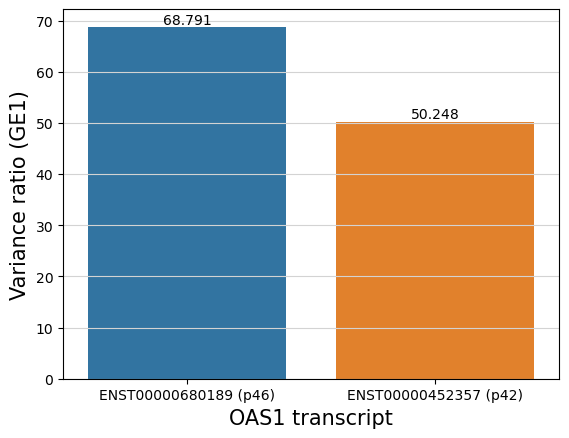

In [312]:
df_ratio = pd.DataFrame({'Transcript' : ['ENST00000680189 (p46)', 'ENST00000452357 (p42)'],
                         'Variance ratio (GE1)' : var_list})


ax = sns.barplot(df_ratio, x='Transcript', y='Variance ratio (GE1)', hue = 'Transcript')

# Add labels on top of bars
for i, v in enumerate(df_ratio['Variance ratio (GE1)']):
    ax.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.xlabel('OAS1 transcript',fontsize=15)
plt.ylabel('Variance ratio (GE1)',fontsize=15)
plt.grid(color='lightgray',axis='y')